In [1]:
# import packages
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")

In [2]:
# Read in files
years = [16, 17, 18, 19, 20, 21, 22]
df_list = []
base_path = "2-FIFA/"

for y in years:
    file = base_path + "female_players_" + str(y) + ".csv"
    df = pd.read_csv(file)
    df_list.append(df)


# Merging procedure

First, from each csv file, only the relevant columns -- "sofifa_id", "overall", "potential", and "dob" -- were retained. Next, the variables that measure athelete performance ("overall" and "potential") were renamed by appending the corresponding year to prepare for later averaging. Before merging, the 2016 dataframe was set as the primary dataframe. To avoid duplication of the overlapping "dob" variable, the "dob" columns were dropped from the remaining dataframes. During merging, the dataframes are joined on the shared column "sofifa_id". After merging, the resulting dataframe only includes players who played consistently from 2016 to 2022.

In [3]:
# Keep only needed columns
cols = ["sofifa_id", "overall", "potential", "dob"]

for i in range(len(df_list)):
    df_list[i] = df_list[i][cols]

In [4]:
# Rename column names for later averaging
for i in range(len(df_list)):
    y = years[i]
    
    df_list[i] = df_list[i].rename(columns={"overall": "overall" + str(y),"potential": "potential" + str(y)})

In [5]:
# Merging

# Set 2016 as the primary dataframe
df_merge = df_list[0]

# Keep dob only in first dataframe to avoid overlapping
for i in range(1, len(df_list)):
    df_list[i] = df_list[i].drop(columns="dob")

# Merge
for i in range(1, len(df_list)):
    df_merge = pd.merge(left=df_merge,right=df_list[i],how="left",on="sofifa_id")


# Cleaning procedure

First, the "overall" and "potential" columns across all years were averaged to create two new columns "avg_overall" and "avg_potential", which represent the average performance of each player. Next, the "dob" column was inspected for missing values and format. After confirming that all "dob" entries are consistent in the "year-month-date" structure, each "dob" entry was split into three strings using hyphens. Then, the revised "dob" column was checked again to ensure that all entires follow the "year", "month", "date" structure. After that, the second component from each entry was extracted to create a new column called "month" to represent the birth month of each player. These months are grouped into four categories: "jan-mar", "apr-jun", "jul-sep", and "oct-dec", and stored in a new column called "month_group". Finally, the final dataframe only retained relevant variables: "sofifa_id", "avg_overall", "avg_potential", and "month_group".

In [6]:
# Compute average overall and potential

# Organize columns
overall_cols = []
potential_cols = []

for y in years:
    overall_cols.append("overall" + str(y))
    potential_cols.append("potential" + str(y))

# Create new columns
df_merge["avg_overall"] = df_merge[overall_cols].mean(axis=1)
df_merge["avg_potential"] = df_merge[potential_cols].mean(axis=1)

In [7]:
# Inspect dob column

# Are there any missing values?
print(df_merge["dob"].isna().sum())

# Are all year, month, and date split by "-"?
print(df_merge["dob"].str.contains("-").mean())
# All year, month, and date split by "-".

0
1.0


In [8]:
# Extract month from dob

# Split dob into year, month, and date
df_merge["dob_parts"] = df_merge["dob"].str.split("-")

# Are all entires split in three parts?
lengths = df_merge["dob_parts"].apply(len)
print(pd.unique(lengths))
# All dob entries are in three parts.

# Extract month, the middle part
def get_month(x):
    return int(x[1])

df_merge["month"] = df_merge["dob_parts"].apply(get_month)

[3]


In [9]:
# Group months
month_group = []

for i in range(len(df_merge)):
    m = df_merge.iloc[i]["month"]
    
    if m <= 3:
        month_group.append("jan-mar")
    elif m <= 6:
        month_group.append("apr-jun")
    elif m <= 9:
        month_group.append("jul-sep")
    else:
        month_group.append("oct-dec")

df_merge["month_group"] = month_group

In [ ]:
# Final clean
df_final = df_merge[["sofifa_id", "avg_overall", "avg_potential", "month_group"]]

# Round all numbers to 2 decimal points
df_final = df_final.round(2)

display(df_final.head())

,sofifa_id,avg_overall,avg_potential,month_group
0,226324,89.50,89.50,jul-sep
1,226328,91.00,91.00,jul-sep
2,226334,90.00,90.00,apr-jun
3,226362,90.00,90.00,jan-mar
4,226373,89.00,89.00,apr-jun
...,...,...,...,...
243,228721,66.50,68.25,apr-jun
244,227385,66.80,69.60,jan-mar
245,227485,64.00,72.00,jul-sep
246,228723,63.50,68.50,jan-mar


# Results
In the original datasets, each player is assigned an overall rating (0–99) based on a weighted combination of attributes that depend on the player’s position in Career Mode from FIFA 15 to FIFA 23. In the cleaned dataset, each player is associated with an average overall rating across years.

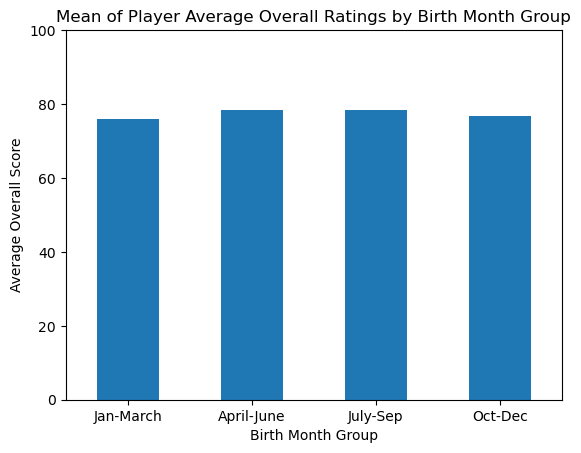

In [ ]:
#Results for players' average overall scores

#Ordering birthday month groups based beginning to end of year
order = ["jan-mar", "apr-jun", "jul-sep", "oct-dec"]
df_final["month_group"] = pd.Categorical(
    df_final["month_group"],
    categories = order,
    ordered = True)

#Calculating mean average overall score for each month group
month_avg = df_final.groupby("month_group")["avg_overall"].mean()

#Bar graph of each birthday month group's average overall score
month_avg.plot(kind = "bar")
plt.title("Mean of Player Average Overall Ratings by Birth Month Group")
plt.xlabel("Birth Month Group")
plt.ylabel("Average Overall Score")
plt.ylim(0, 100)
plt.xticks(rotation = 0, ticks = [0,1,2,3], labels = ["Jan-March", "April-June", "July-Sep", "Oct-Dec"])
plt.show()

After grouping players by birth month category and computing the mean of these average ratings, the resulting bar graph shows only small differences between groups. This indicates that average player ratings are relatively similar across birth month groups. Therefore, there is no clear evidence from this analysis that birth month is strongly associated with differences in player overall ratings.

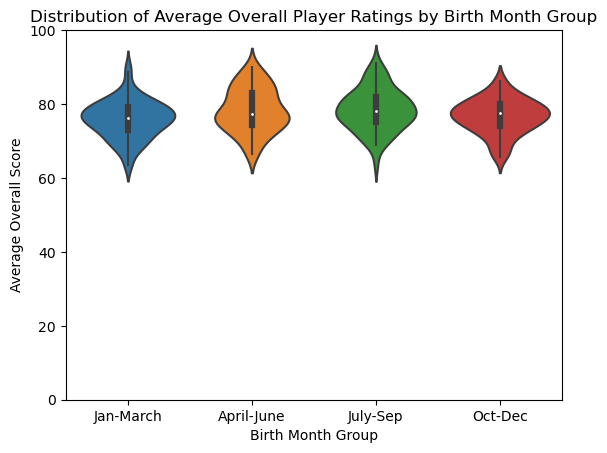

In [12]:
#Violin plot of each birthday month group's average overall score
sns.violinplot(x = "month_group", y = "avg_overall", data = df_final)
plt.title("Distribution of Average Overall Player Ratings by Birth Month Group")
plt.xlabel("Birth Month Group")
plt.ylabel("Average Overall Score")
plt.ylim(0, 100)
plt.xticks(ticks = [0,1,2,3], labels = ["Jan-March", "April-June", "July-Sep", "Oct-Dec"])
plt.show()

Because bar graphs only summarize the mean, we further analyzed whether there was any differences in distribution of players' average overall ratings within each birth month group. The violin plot displays the full distribution of values, including the spread, density, and range of ratings in each group.

Across all four birth month groups, the shapes of the distributions appear very similar, with the median values and interquartile ranges closely aligned. This indicates that not only are the average ratings similar, but the variability of player ratings within each group is comparable as well. Overall, this suggests that there are no meaningful differences in the distribution of player ratings across birth month groups, further supporting the observation that birth month is not strongly associated with differences in player ability in this dataset.

To further analyze the data, we looked at each players' potential, which is assigned a number from 0 to 99. In the FIFA game, the potential indicates how good the player can become in the future, so the higher the potential, the better the player. First, we will plot the mean of players' average potential ratings by birth month group.

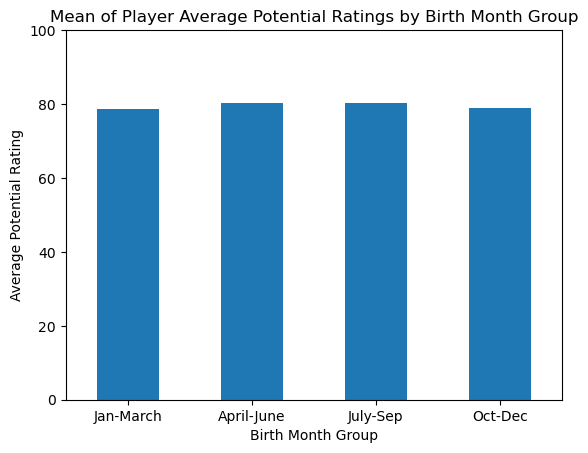

In [13]:
# Calculate the mean average potential rating for each month group
month_potential_avg = df_final.groupby(by="month_group")["avg_potential"].mean()

# Create bar graph of each month group's mean potential rating
month_potential_avg.plot(kind = "bar")
plt.title("Mean of Player Average Potential Ratings by Birth Month Group")
plt.xlabel("Birth Month Group")
plt.ylabel("Average Potential Rating")
plt.ylim(0, 100)
plt.xticks(rotation = 0, ticks = [0,1,2,3], labels = ["Jan-March", "April-June", "July-Sep", "Oct-Dec"])
plt.show()

Like the bar graph for the average overall ratings, differences between each birth group is relatively small. This makes sense, since a player with a higher overall rating is more likely to have a higher potential rating. Once again, there is no clear evidence to show that birth month is strongly associated with differences in player potential. 

Let's take a closer look at each of the birth month groups. In the FIFA game, there are four different statuses that a player can have depending on their potential rating:

"Has potential to be special": 91 and higher
</br>
"Exciting prospect": 86 - 90
</br>
"Showing great potential": 80 - 85
</br>
"At club since": less than 79
</br>

For conciseness, these statuses will be referred to respectively as: "Special", "Exciting", "Great", and "Lower". We will use a catplot ("categorical plot") from the Seaborn library to show the breakdown of potential statuses in for each birth month group.

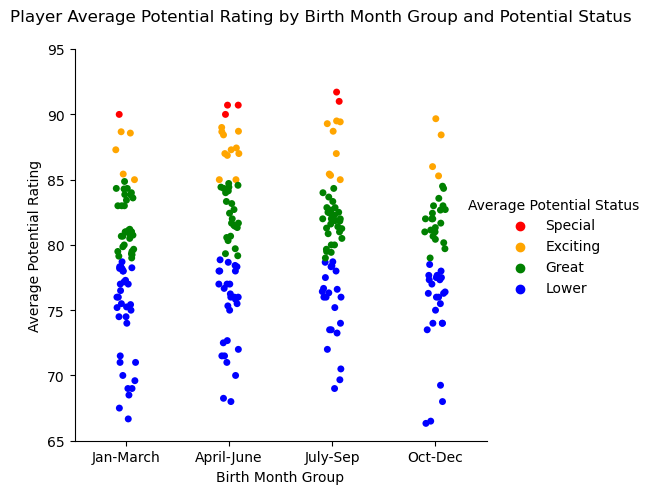

In [14]:
# Recode data into the potential statuses
potential_bins = [-np.inf, 79, 85, 90, np.inf]
potential_labels = ["Lower", "Great", "Exciting", "Special"]
df_final["avg_potential_status"] = pd.cut(x = df_final["avg_potential"], bins = potential_bins, labels = potential_labels, right = False)

# Plot using Seaborn catplot, indicating different potential statuses with different colors
g = sns.catplot(data = df_final, x = "month_group", y = "avg_potential", 
                hue = "avg_potential_status", 
                hue_order = ["Special", "Exciting", "Great", "Lower"],
                palette = {"Special":"red", "Exciting":"orange", "Great":"green", "Lower":"blue"})
g.axes[0,0].set_ylim(65, 95)
g.set_xticklabels(["Jan-March", "April-June", "July-Sep", "Oct-Dec"])
g.set_axis_labels("Birth Month Group", "Average Potential Rating")
g.figure.suptitle("Player Average Potential Rating by Birth Month Group and Potential Status")
g.figure.subplots_adjust(top=0.9)
g.legend.set_title("Average Potential Status")
plt.show()

The catplot shows that the April-July and July-September birth month groups have more players with the "Special" potential status than the other two month groups. However, this analysis has a sample size of 247 players, and so this catplot is not enough evidence to prove that one birth month group produces players that are more likely to have higher potential than other birth month groups. Further analyses using larger datasets should be considered to assess if there truly is an association between birth month group and player ability.